# Heart Disease Prediction by using ML
## 1. Problem Definition 
Predict whether individual has heart disease or not according given features
## 2. Data Introduction
* Data was obtained from [Kaggle](https://www.kaggle.com/datasets/sumaiyatasmeem/heart-disease-classification-dataset).

## 3. Features
We've got 13 features, and 1 target in the dataset, and it's described as below.

1. **age** - age in years

2. **sex** - gender
    * 1 : male
    * 0 : female

3. **cp** - Chest pain type
    * 0 : typical angina
    * 1 : atypical angina
    * 2 : non — anginal pain
    * 3 : asymptotic

4. **trestbps**- resting blood pressure in mmHg (unit)
    * anything above 130-140 is typically cause for concern.

5. **chol**- Serum Cholestrol in mg/dl (unit)

6. **fbs**- Fasting Blood Sugar
    * fasting blood sugar > 120mg/dl
        * 1 = true
        * 0 = false
    * '>126' mg/dL represents diabetes

7. **restecg** - resting electrocardiographic
    * 0 : normal
    * 1 : having ST-T wave abnormality
    * 2 : left ventricular hyperthrophy

8. **thalach**- maximum heart rate

9. **exang**- Exercise induced angina
    * 1 : yes
    * 0 : no

10. **oldpeak**- ST depression induced by exercise relative to rest looks at stress of heart during excercise unhealthy heart will stress more

11. **slope** - Slope of the peak exercise ST segment
    * 0 : upsloping -  better heart rate with excercise (uncommon)
    * 1 : flat -  minimal change (typical healthy heart)
    * 2 : downsloping - signs of unhealthy heart

12. **ca** - Number of major vessels (0–3) colored by flourosopy
    * colored vessel means the doctor can see the blood passing through
    * the more blood movement the better (no clots)

13. **thal** - Displays the thalassemia
    * 1,3 : normal
    * 6 : fixed defect
    * 7 : reversible defect (no proper blood movement when excercising)

14. **target** - A patient has heart diseas or not
    * 1 : yes
    * 0 : no

In [52]:
data_dict = {
'age':'age in years',
'sex': '0 = female | 1 = male',
'cp' : 'chest pain type; 0=typical angina | 1=atypical angina | 2 : non — anginal pain | 3 : asymptotic',
'trestbps' : 'resting blood pressure in mmHg (unit)',
'chol' : 'Serum Cholestrol in mg/dl (unit)',
'fbs' : 'Fasting Blood Sugar',
'restecg': 'resting electrocardiographic',
'thalach': 'maximum heart rate',
'exang': 'Exercise induced angina',
'oldpeak':'ST depression induced by exercise relative to rest looks at stress of heart during excercise unhealthy heart will stress more',
'slope' : 'Slope of the peak exercise ST segment',
'ca' : 'Number of major vessels (0–3) colored by flourosopy',
'thal' : 'Displays the thalassemia'
}

In [2]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

# Models
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# metrics
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, f1_score, recall_score, precision_score


## 4. EDA

In [16]:
df = pd.read_csv('./data/heart-disease.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [28]:
print(df.isna().sum())
print("===================================")
df.info()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


The data has already been cleaned.

It's all numerical.

Checking the describe Statistics

In [19]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### 4.1 Checking if class balanced

target
1    165
0    138
Name: count, dtype: int64


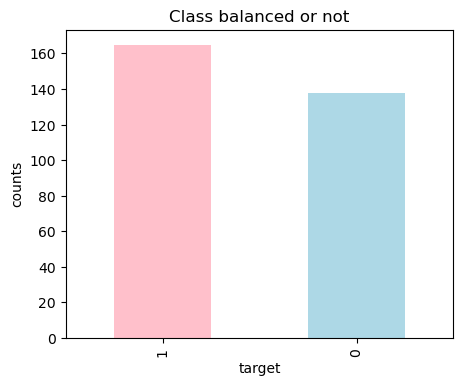

In [45]:
print(df["target"].value_counts())

df["target"].value_counts().plot(kind = "bar",
                                figsize = (5, 4),
                                color = ['pink', 'lightblue'])
plt.title("Class balanced or not")
plt.ylabel("counts");

#### Checking Heart Disease Frequency with Sex
0 = 'female'

1 = 'male'

In [87]:
pd.crosstab(df['target'],df['sex'])

sex,0,1
target,,
0,24,114
1,72,93


sex
1    207
0     96
Name: count, dtype: int64


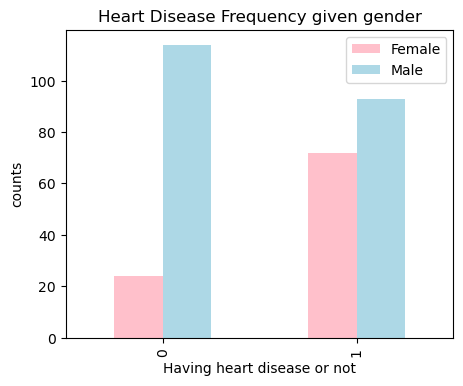

In [83]:
print(df['sex'].value_counts())
pd.crosstab(df['target'], df['sex']).plot(kind = 'bar',
                             color = ['pink', 'lightblue'],
                             figsize = (5,4))
plt.title("Heart Disease Frequency given gender")
plt.legend(["Female", "Male"])
plt.xlabel("Having heart disease or not")
plt.ylabel("counts");

We have more males than females in the dataset. Among males, the difference between those with and without heart disease is relatively small. In contrast, heart disease frequency among females is quite imbalanced. The number of females with heart disease is more than three times that of those without. This imbalance may introduce bias when training models. we can keep this in mind.

Next, we'll check the distribution of age

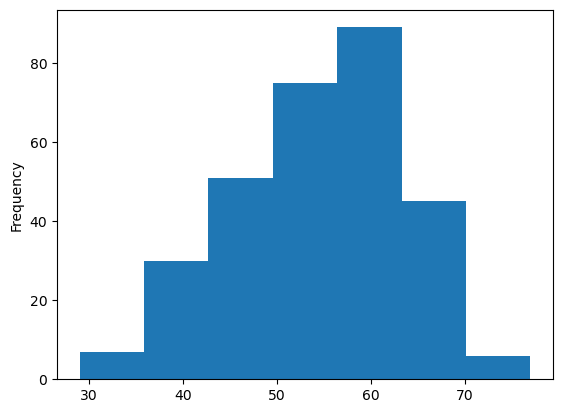

In [112]:
df['age'].plot.hist(bins = 7);

The majority of individuals in the dataset fall between the age of 55 and 65.

Let's make correlation matrix to check which features have stronger relationsip with the target

In [113]:
# correlation

df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


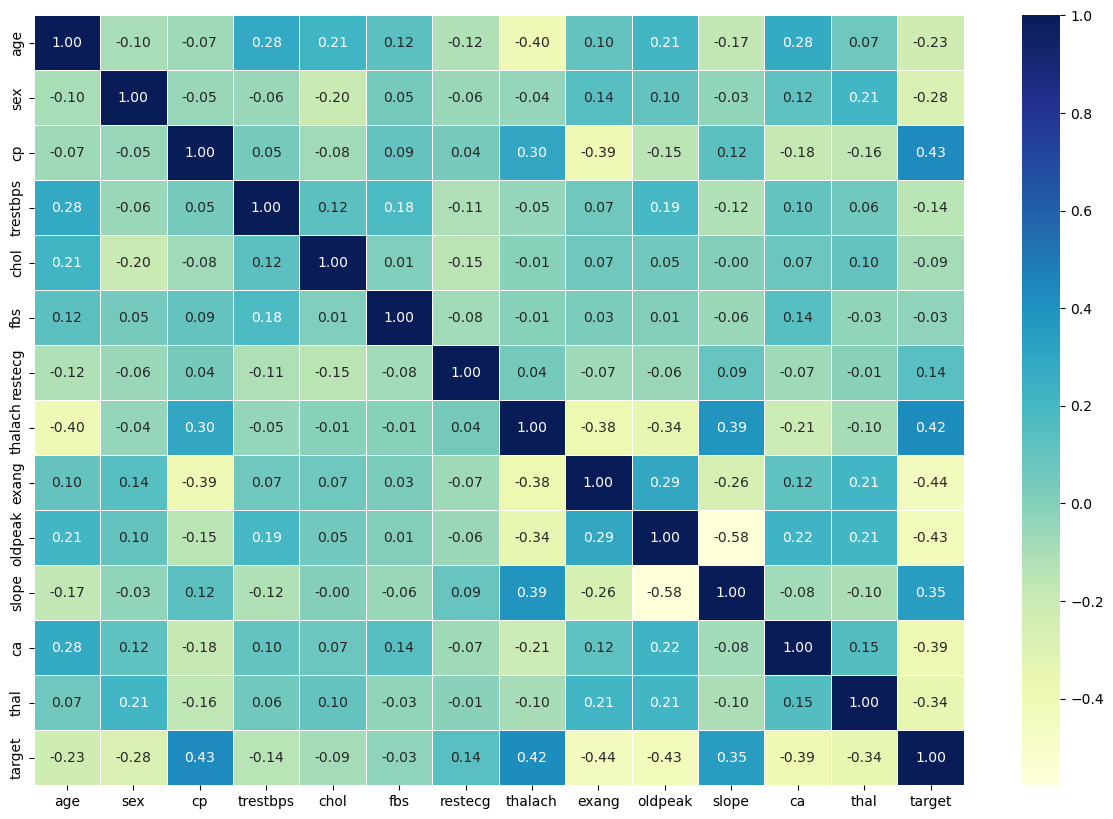

In [129]:
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize = (15, 10))
ax = sns.heatmap(corr_matrix,
                annot = True,
                linewidth = 0.5,
                fmt = ".2f",
                cmap = "YlGnBu")

From the correlation matrix, several important relationshiops can be observed

The correlation matrix shows that cp and thalach have relatively strong positive correlations with the target, while exang and oldpeak exhibit relatively strong negative correlations.

### 5. Modelling

#### 5.1 Split the data into training and test set

In [138]:
from sklearn.model_selection import train_test_split

X = df.drop(['target'], axis = 1)
y = df['target'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [146]:
# Checking the dataset

X_train.shape, X_test.shape, y_train.shape, y_test.shape
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
25,71,0,1,160,302,0,1,162,0,0.4,2,2,2
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2
140,51,0,2,120,295,0,0,157,0,0.6,2,0,2
42,45,1,0,104,208,0,0,148,1,3.0,1,0,2
54,63,0,2,135,252,0,0,172,0,0.0,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
178,43,1,0,120,177,0,0,120,1,2.5,1,0,3
27,51,1,2,110,175,0,1,123,0,0.6,2,0,2
297,59,1,0,164,176,1,0,90,0,1.0,1,2,1


In [147]:
y_train

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1])

#### 5.2 Model Selection

**I am trying the following ML models:**

Models are selected by referring to the [map](https://scikit-learn.org/stable/machine_learning_map.html). Additionally, since this is a binary classification problem, `Logistic Regression` and `Random Forest` are also considered.

1. LinearSVC
3. K-Nearest Neighbors Classifier
4. Logistic Regression
5. Random Forest Classifier

#### 5.3 Fit models

##### Linear SVC

In [154]:
lsvc_clf = LinearSVC()
lsvc_clf.fit(X_train, y_train)
lsvc_clf.score(X_test, y_test)

0.7704918032786885

In [157]:
# Checking default hyperparameters

lsvc_clf.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': 'auto',
 'fit_intercept': True,
 'intercept_scaling': 1,
 'loss': 'squared_hinge',
 'max_iter': 1000,
 'multi_class': 'ovr',
 'penalty': 'l2',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

### 6. Model Evaluation
### 7. Feature Importance